# OverallQual, the grade from 1 to 10

`OverallQual` is an integer grade of material and finish. It is the strongest single clue in the file, and it is already on a scale you can sort.

| Grade | Houses | Median price |
|---:|---:|---:|
| 1 | 2 | 50150 |
| 2 | 3 | 60000 |
| 3 | 20 | 86250 |
| 4 | 116 | 108000 |
| 5 | 397 | 133000 |
| 6 | 374 | 160000 |
| 7 | 319 | 200141 |
| 8 | 168 | 269750 |
| 9 | 43 | 345000 |
| 10 | 18 | 432390 |

The counts add to 1460. The median rises at every step. House 1 has grade 7, whose median is 200141, and it sold for 208500, just above that grade's median.

Grades 1 and 2 together are 5 houses. A story about "grade 1" is a story about two sales. The middle of the file is grade 5 and grade 6: $397 + 374 = 771$ houses.


In [2]:
# Locate the contest tables beside this notebook, or under the course root.
from pathlib import Path
import csv

def manifest_path(name):
    here = Path.cwd()
    for folder in [here, *here.parents]:
        nested = folder / "15-House Prices" / "data" / name
        direct = folder / "data" / name
        if nested.exists():
            return nested
        if direct.exists() and (folder / "data" / "data_description.txt").exists():
            return direct
    raise FileNotFoundError(name)

def read_manifest(name):
    with manifest_path(name).open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

train = read_manifest("train.csv")
test = read_manifest("test.csv")
submission = read_manifest("sample_submission.csv")
print(len(train), len(test), len(submission))
print(train[0]["Id"], train[0]["SalePrice"])


1460 1459 1459
1 208500


In [3]:
# Median price inside each quality grade.
from fractions import Fraction
from collections import defaultdict
groups = defaultdict(list)
for row in train:
    groups[int(row["OverallQual"])].append(int(row["SalePrice"]))

def median(values):
    ordered = sorted(values)
    count = len(ordered)
    if count % 2 == 1:
        return Fraction(ordered[count // 2])
    return Fraction(ordered[count // 2 - 1] + ordered[count // 2], 2)

expected = {
    1: (2, 100300, 50150),
    2: (3, 155311, 60000),
    3: (20, 1749475, 86250),
    4: (116, 12576796, 108000),
    5: (397, 53008769, 133000),
    6: (374, 60439535, 160000),
    7: (319, 66261539, 200141),
    8: (168, 46155570, 269750),
    9: (43, 15803060, 345000),
    10: (18, 7894591, 432390),
}
for grade in range(1, 11):
    count, total, mid = expected[grade]
    print(grade, len(groups[grade]), sum(groups[grade]), median(groups[grade]))
    assert len(groups[grade]) == count
    assert sum(groups[grade]) == total
    assert median(groups[grade]) == Fraction(mid)
assert sum(len(groups[grade]) for grade in range(1, 11)) == 1460
assert 397 + 374 == 771


1 2 100300 50150
2 3 155311 60000
3 20 1749475 86250
4 116 12576796 108000
5 397 53008769 133000
6 374 60439535 160000
7 319 66261539 200141
8 168 46155570 269750
9 43 15803060 345000
10 18 7894591 432390


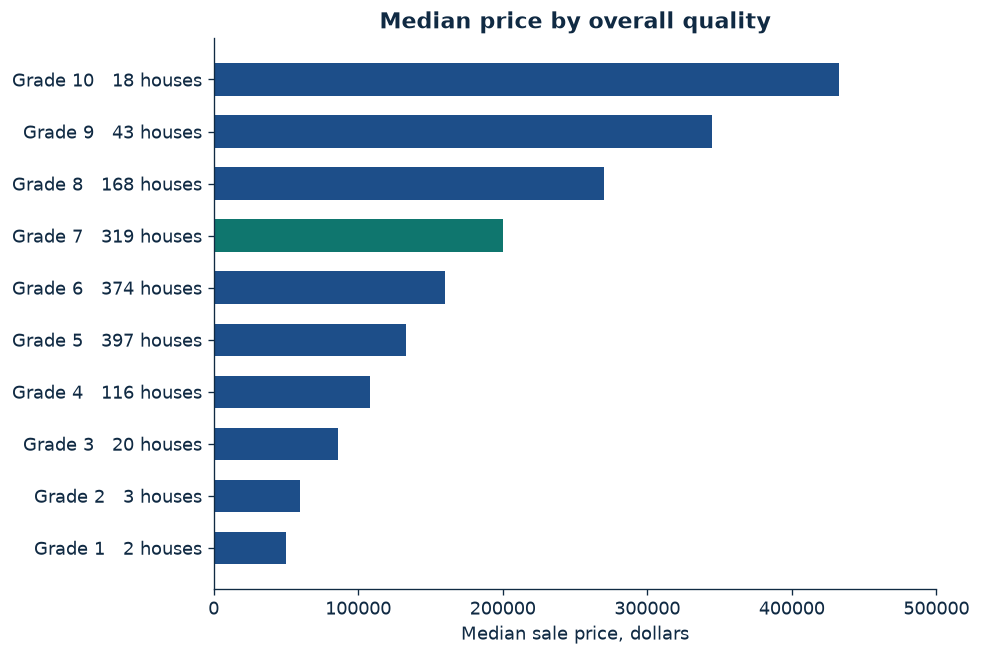

In [4]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#102a43",
    "axes.labelcolor": "#102a43",
    "xtick.color": "#102a43",
    "ytick.color": "#102a43",
    "text.color": "#102a43",
})
# Ten medians, drawn from zero so grade 10 does not inflate the scale.
from fractions import Fraction
from collections import defaultdict
groups = defaultdict(list)
for row in train:
    groups[int(row["OverallQual"])].append(int(row["SalePrice"]))

def median(values):
    ordered = sorted(values)
    count = len(ordered)
    if count % 2 == 1:
        return Fraction(ordered[count // 2])
    return Fraction(ordered[count // 2 - 1] + ordered[count // 2], 2)

grades = list(range(1, 11))
mids = [float(median(groups[grade])) for grade in grades]
counts = [len(groups[grade]) for grade in grades]
figure, axis = plt.subplots(figsize=(8.4, 5.6))
positions = list(range(10))
colors = ["#1d4e89"] * 10
colors[6] = "#0f766e"
axis.barh(positions, mids, color=colors, height=0.62)
axis.set_yticks(
    positions,
    [f"Grade {grade}   {count} houses" for grade, count in zip(grades, counts)],
)
axis.set_xlim(0, 500000)
axis.set_xlabel("Median sale price, dollars")
axis.set_title("Median price by overall quality")
figure.tight_layout()


## Pitfall

The green bar is grade 7, the grade of house 1. Its median, 200141, is one house in the middle of 319 sales, not a rounded version of 200000. Using 200000 in its place is a different number.

## Summary

Ten grades, and the median price rises from 50150 to 432390. Grades 5 and 6 contain 771 of the 1460 sales.
